# 이벤트 스터디 (Event Study) — CAR 분석
## 지정학적 위기 시 비트코인은 디지털 금인가?

> 상세 내용은 [README.md](README.md) 참조

- 이벤트 창: **±17 거래일** (전체 이벤트 공통 최소 확보 가능 일수)
- 추정 기간: **[-120, -26] 거래일**
- 판단 기준: Baur & Lucey (2010) — CAR > 0 & p < 0.05 → Safe Haven


---
## Step 0. 라이브러리


In [1]:
# !pip install pandas numpy matplotlib scipy statsmodels --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings, os, platform
warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130

# ── 이벤트 정의 (1827행 master_data.csv 이벤트명과 정확히 일치) ──
EVENT_DATES = {
    'hormuz_crisis'          : '2019-06-13',
    'soleimani_assassination': '2020-01-03',
    'russia_ukraine_war'     : '2022-02-24',
    'israel_hamas_war'       : '2023-10-07',
    'israel_iran'            : '2024-04-01',
    'us_israel_iran'         : '2026-02-28',
}
EVENT_LABELS = {
    'hormuz_crisis'          : '호르무즈 위기',
    'soleimani_assassination': '솔레이마니 암살',
    'russia_ukraine_war'     : '러-우 전쟁',
    'israel_hamas_war'       : '이스라엘-하마스',
    'israel_iran'            : '이스라엘-이란 충돌',
    'us_israel_iran'         : '이란 전쟁',
}
ASSETS      = ['BTC', 'Gold', 'TLT', 'DXY', 'NASDAQ']
CMRM_ASSETS = ['Gold', 'DXY']
MM_ASSETS   = ['Gold', 'TLT', 'DXY', 'NASDAQ']
MARKET      = 'SP500'

# ── 이벤트 창 + 추정 기간 ──────────────────────────────
EVENT_WINDOW = 17        # ±N 거래일 (이벤트창)
EST_START    = -120      # 추정 기간 시작 (이벤트 전 120거래일)
EST_END      = -26       # 추정 기간 끝   (이벤트 전 26거래일)
N_BOOT       = 5000      # Bootstrap 반복수

ASSET_COLORS = {
    'BTC'   : '#F7931A',
    'Gold'  : '#DAA520',
    'TLT'   : '#2196F3',
    'DXY'   : '#9C27B0',
    'NASDAQ': '#E91E63',
}

# ── 정본 입력 경로 (1827행 master_data + returns) ──
MASTER_PATH  = '../master_data/result_csv_png/master_data.csv'
RETURNS_PATH = '../master_data/result_csv_png/returns.csv'

# ── 결과 출력 디렉토리 (표준화) ──
RESULTS_DIR  = 'result_csv_png'
os.makedirs(RESULTS_DIR, exist_ok=True)

print('✅ 환경 설정 완료')
print(f'   이벤트 창: ±{EVENT_WINDOW} 거래일')
print(f'   추정 기간: [{EST_START}, {EST_END}] 거래일 (길이 {EST_END-EST_START+1}일)')
print(f'   Bootstrap: {N_BOOT:,}회')
print(f'   master   : {MASTER_PATH}')
print(f'   returns  : {RETURNS_PATH}')
print(f'   results  : {RESULTS_DIR}/')


✅ 환경 설정 완료
   이벤트 창: ±17 거래일
   추정 기간: [-120, -26] 거래일 (길이 95일)
   Bootstrap: 5,000회
   master   : ../master_data/master_data.csv
   returns  : ../master_data/returns.csv
   results  : ./


---
## Step 1. 데이터 로드


In [3]:
# ── master_data.csv (정본 1827행) ──────────────────────
if not os.path.exists(MASTER_PATH):
    raise FileNotFoundError(f'{MASTER_PATH} 없음')

master = pd.read_csv(MASTER_PATH)
master['date']       = pd.to_datetime(master['date'])
master['event_date'] = pd.to_datetime(master['event_date'])
for col in ASSETS + [MARKET, 'GPR_custom', 'VIX', 'fear_greed_lag1']:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors='coerce')

# ── returns.csv (추정 기간용 전체 수익률, 1843행) ───────
if not os.path.exists(RETURNS_PATH):
    raise FileNotFoundError(f'{RETURNS_PATH} 없음')

ret_all = pd.read_csv(RETURNS_PATH)
ret_all.columns = [c.strip() for c in ret_all.columns]
if 'Date' in ret_all.columns:
    ret_all = ret_all.rename(columns={'Date': 'date'})
ret_all['date'] = pd.to_datetime(ret_all['date'])
ret_all = ret_all.sort_values('date').reset_index(drop=True)
for col in ASSETS + [MARKET]:
    if col in ret_all.columns:
        ret_all[col] = pd.to_numeric(ret_all[col], errors='coerce')

print(f'✅ master_data : {len(master)}행  '
      f'({master["date"].min().date()} ~ {master["date"].max().date()})')
print(f'✅ returns_all : {len(ret_all)}행  '
      f'({ret_all["date"].min().date()} ~ {ret_all["date"].max().date()})')

# ── 이벤트명 일치 확인 ─────────────────────────────────
missing = sorted(set(EVENT_DATES) - set(master['event_name'].dropna().unique()))
extra   = sorted(set(master['event_name'].dropna().unique()) - set(EVENT_DATES))
print(f'\n이벤트명 일치 확인:')
if not missing and not extra:
    print('  ✅ EVENT_DATES와 데이터 event_name 완전 일치')
else:
    if missing: print(f'  ❌ EVENT_DATES에만 있음: {missing}')
    if extra:   print(f'  ⚠️ 데이터에만 있음: {extra}')

print(f'\n이벤트별 거래일 / 기준일 전·후:')
print(f'{"이벤트":<30} {"전체":>5} {"기준일전":>8} {"기준일후":>8} {"창 충족":>8}')
print('-' * 65)
for ev, ed in EVENT_DATES.items():
    sub    = master[master['event_name']==ev].sort_values('date')
    ed_ts  = pd.Timestamp(ed)
    before = len(sub[sub['date'] < ed_ts])
    after  = len(sub[sub['date'] >= ed_ts])
    ok     = '✅' if before >= EVENT_WINDOW and after >= EVENT_WINDOW else '⚠️ 부족'
    print(f'{ev:<30} {len(sub):>5} {before:>8} {after:>8} {ok:>8}')


✅ master_data : 1827행  (2019-01-02 ~ 2026-04-30)
✅ returns_all : 1842행  (2019-01-02 ~ 2026-04-30)

이벤트명 일치 확인:
  ✅ EVENT_DATES와 데이터 event_name 완전 일치

이벤트별 거래일 / 기준일 전·후:
이벤트                               전체     기준일전     기준일후     창 충족
-----------------------------------------------------------------
hormuz_crisis                    182      112       70        ✅
soleimani_assassination          339       70      269        ✅
russia_ukraine_war               475      270      205        ✅
israel_hamas_war                 260      201       59        ✅
israel_iran                      299       59      240        ✅
us_israel_iran                   272      229       43        ✅


---
## Step 2. 추정 기간 슬라이싱

`master_data.csv`는 이벤트 창만 포함 → 추정 기간 `[-120, -26]`은 `returns.csv`에서 슬라이싱


In [4]:
def get_estimation_data(event_date_str, returns_df,
                        est_start=EST_START, est_end=EST_END):
    """
    returns_df 전체에서 이벤트 기준일 기준 [est_start, est_end] 거래일 슬라이싱
    """
    ed  = pd.Timestamp(event_date_str)
    idx = returns_df[returns_df['date'] >= ed].index
    if len(idx) == 0:
        return pd.DataFrame()
    ei = idx[0]
    s  = max(0, ei + est_start)   # EST_START = -120
    e  = max(0, ei + est_end)     # EST_END   = -26
    if s > e:
        return pd.DataFrame()
    return returns_df.iloc[s:e+1].copy()

estimation_data = {}
for event, date in EVENT_DATES.items():
    est = get_estimation_data(date, ret_all)  
    estimation_data[event] = est

    if len(est) >= 20:
        print(f'{event:<30} {str(est["date"].min().date()):>13} '
              f'{str(est["date"].max().date()):>13} {len(est):>6}')
    else:
        print(f'{event:<30} ⚠️ 추정 데이터 부족 ({len(est)}일)')

hormuz_crisis                     2019-01-02    2019-05-07     87
soleimani_assassination           2019-07-15    2019-11-25     95
russia_ukraine_war                2021-09-02    2022-01-18     95
israel_hamas_war                  2023-04-18    2023-08-31     95
israel_iran                       2023-10-06    2024-02-22     95
us_israel_iran                    2025-09-08    2026-01-22     95


In [5]:
# (데이터 로드 직후, 출력문 전 단계에 추가 권장)

# 1. master에 있는 GPR 데이터를 ret_all에 붙여주기
if 'GPR_custom' in master.columns:
    gpr_to_merge = master[['date', 'GPR_zscore']].drop_duplicates()
    ret_all = pd.merge(ret_all, gpr_to_merge, on='date', how='left')
    
    # 만약 GPR_custom이 수익률 형태가 아니라 '지수' 형태라면 변화율을 만들어줍니다.
    # (제공해주신 데이터 샘플 0.67... 형태라면 이미 변화율이므로 이 단계는 생략 가능)
    # ret_all['GPR_ret'] = ret_all['GPR_custom'].pct_change() 

print(f"✅ ret_all 내 GPR 데이터 포함 여부: {'GPR_zscore' in ret_all.columns}")

✅ ret_all 내 GPR 데이터 포함 여부: True


---
## Step 3. 정상 수익률 추정

- **BTC·Gold·DXY → CMRM**: 추정 기간 평균 수익률 μ
- **NASDAQ·TLT → Market Model**: OLS (독립변수: SP500)


**정상 수익률 모델 선택 근거**

- BTC에 Market Model 적용 시 β 극심 변동(0.03~1.06), R² 불안정 → CMRM 채택
- Gold·DXY: Market Model R²=0.00~0.04 → CMRM으로 변경
- TLT: R²≈0.25, β 음수 → Market Model 유지


In [6]:
import pandas as pd
import numpy as np
from statsmodels.api import OLS, add_constant

# [설정] 자산별 적합한 시장 벤치마크 유지
ASSET_BENCHMARKS = {
    'BTC': 'NASDAQ',
    'Gold': 'SP500',
    'TLT': 'SP500',
    'DXY': 'SP500',
    'NASDAQ': 'SP500'
}

# [설정] 시장 지수와 상관성이 낮은 자산은 평균 모델 사용
CMRM_ASSETS = ['Gold', 'DXY'] 

def estimate_normal_return_v3(est_df, asset, cmrm_assets):
    """
    GPR을 제외하고 자산별 벤치마크를 기반으로 한 정상 수익률 추정
    """
    if asset not in est_df.columns:
        return None
        
    y = est_df[asset].dropna()

    # 1. CMRM(평균 수익률 모델) 적용
    if asset in cmrm_assets:
        mu = y.mean()
        return {'model': 'CMRM', 'mu': mu, 'alpha': 0, 'beta': 0, 'r2': 0, 'n': len(y)}

    # 2. Market Model (단일 회귀) 적용
    market = ASSET_BENCHMARKS.get(asset, 'SP500')
    
    # 벤치마크 지수가 데이터에 있는지 확인
    if market not in est_df.columns:
        return {'model': 'ERROR', 'reason': f'Benchmark({market}) Missing'}
        
    # 자산과 시장 지수 날짜 일치
    combined = pd.concat([y, est_df[market]], axis=1).dropna()
    
    if len(combined) < 20:
        return {'model': 'FAILED', 'reason': 'Insufficient data'}

    y_sync = combined.iloc[:, 0]
    X_sync = combined.iloc[:, 1] # Market 지수만 사용

    # 단일 회귀 분석 (Alpha + Beta)
    X = add_constant(X_sync)
    res = OLS(y_sync, X).fit()
    
    return {
        'model' : f'MM({market})',
        'mu'    : None,
        'alpha' : res.params.iloc[0],
        'beta'  : res.params.iloc[1],
        'r2'    : res.rsquared,
        'n'     : len(y_sync)
    }

# --- 실행 및 결과 출력 ---
models = {}
print(f'{"이벤트":<25} {"자산":<8} {"모델":<16} {"파라미터 결과 (α / β / R² / n)"}')
print('-' * 110)

for event, date in EVENT_DATES.items():
    est = estimation_data.get(event, pd.DataFrame())
    
    if est.empty or len(est) < 20:
        continue
        
    models[event] = {}
    for asset in ASSETS:
        if asset not in est.columns: continue
        
        m = estimate_normal_return_v3(est, asset, CMRM_ASSETS)
        
        if m is None: continue
        if m['model'] in ['FAILED', 'ERROR']:
            # 실패 원인 확인이 필요하면 아래 주석을 해제하세요
            # print(f"{event:<25} {asset:<8} {m['model']}: {m['reason']}")
            continue
            
        models[event][asset] = m
        
        # 출력 가독성 처리
        if m['model'] == 'CMRM':
            res_str = f'μ={m["mu"]:+.5f} (평균 모델)'
        else:
            res_str = f'α={m["alpha"]:+.5f} β={m["beta"]:+.3f} R²={m["r2"]:.2f} (n={m["n"]})'
            
        print(f'{event:<25} {asset:<8} {m["model"]:<16} {res_str}')

이벤트                       자산       모델               파라미터 결과 (α / β / R² / n)
--------------------------------------------------------------------------------------------------------------
hormuz_crisis             BTC      MM(NASDAQ)       α=+0.00426 β=+0.399 R²=0.02 (n=87)
hormuz_crisis             Gold     CMRM             μ=+0.00005 (평균 모델)
hormuz_crisis             TLT      MM(SP500)        α=+0.00091 β=-0.363 R²=0.24 (n=87)
hormuz_crisis             DXY      CMRM             μ=+0.00017 (평균 모델)
hormuz_crisis             NASDAQ   MM(SP500)        α=+0.00011 β=+1.236 R²=0.93 (n=87)
soleimani_assassination   BTC      MM(NASDAQ)       α=-0.00521 β=-0.181 R²=0.00 (n=95)
soleimani_assassination   Gold     CMRM             μ=+0.00034 (평균 모델)
soleimani_assassination   TLT      MM(SP500)        α=+0.00100 β=-0.527 R²=0.25 (n=95)
soleimani_assassination   DXY      CMRM             μ=+0.00016 (평균 모델)
soleimani_assassination   NASDAQ   MM(SP500)        α=+0.00001 β=+1.157 R²=0.95 (n=95)
russia

---
## Step 4. AR / CAR 산출

이벤트 창 `[-17, +17]` 슬라이싱 → `AR(t) = 실제 − 정상`, `SAR(t) = AR / σ_est`


**SAR·CSAR 도입 배경**

- SAR: AR을 추정기 변동성(σ_est)으로 표준화 → BMP 검정 기반
- SAR ≥ 2.0: 95% 신뢰수준에서 유의미한 비정상 수익률


In [7]:
def normal_return(row_dict, params):
    """t일 정상 수익률 (자산별 매핑된 시장 지수 동적 적용)"""
    if params['model'] in ('CMRM', 'CMRM(대체)', 'CMRM'):
        return params['mu']
    
    # 모델명에서 시장 지수 추출 (예: "MM(NASDAQ)" -> "NASDAQ")
    import re
    m = re.search(r'\((.*?)\)', params['model'])
    market_name = m.group(1) if m else 'SP500' # 기본값
    
    r_mkt = row_dict.get(market_name)
    
    # 시장 데이터가 없으면 계산 불가하므로 NaN 반환 후 위에서 스킵하게 함
    if r_mkt is None or pd.isna(r_mkt):
        return np.nan
        
    return params['alpha'] + params['beta'] * r_mkt

# 1. 모델 추정 함수 수정 (표준편차/RMSE 추출 추가)
def estimate_normal_return_v4(est_df, asset, cmrm_assets):
    if asset not in est_df.columns:
        return None
    
    y = est_df[asset].dropna()
    market = ASSET_BENCHMARKS.get(asset, 'SP500')
    
    if asset in cmrm_assets:
        mu = y.mean()
        # CMRM의 변동성은 수익률의 표준편차로 계산
        sigma = y.std() 
        return {'model': 'CMRM', 'mu': mu, 'alpha': 0, 'beta': 0, 'sigma': sigma, 'n': len(y)}

    if market not in est_df.columns:
        return None
        
    combined = pd.concat([y, est_df[market]], axis=1).dropna()
    if len(combined) < 20:
        return {'model': 'FAILED', 'reason': 'Insufficient data'}

    y_sync = combined.iloc[:, 0]
    X_sync = add_constant(combined.iloc[:, 1])
    res = OLS(y_sync, X_sync).fit()
    
    return {
        'model' : f'MM({market})',
        'alpha' : res.params.iloc[0],
        'beta'  : res.params.iloc[1],
        'sigma' : np.sqrt(res.mse_resid), # 회귀분석의 표준오차(RMSE)
        'r2'    : res.rsquared,
        'n'     : len(y_sync)
    }

# 2. CAR 계산 로직 수정 (SAR 및 변동성 조정 추가)
def compute_car_with_vol(event, date_str, master_df, model_dict, window=EVENT_WINDOW):
    ed = pd.Timestamp(date_str)
    sub = (master_df[master_df['event_name'] == event]
           .sort_values('date').reset_index(drop=True))

    idx = sub[sub['date'] >= ed].index
    if len(idx) == 0: return {}
    ep = idx[0]

    result = {}
    for asset in ASSETS:
        if asset not in sub.columns or model_dict.get(asset) is None:
            continue
        
        params = model_dict[asset]
        sigma_est = params['sigma'] # 추정 기간의 평소 변동성
        rows = []
        
        for offset in range(-window, window + 1):
            pos = ep + offset
            if pos < 0 or pos >= len(sub): continue
            
            row = sub.iloc[pos]
            actual = row[asset]
            if pd.isna(actual): continue
            
            nr = normal_return(row.to_dict(), params)
            if pd.isna(nr): continue
            
            ar = actual - nr
            # SAR: 비정상 수익률을 평소 변동성으로 나눔 (분산 변화 반영)
            sar = ar / sigma_est if sigma_est > 0 else 0 
            
            rows.append({
                'date': row['date'],
                'day_offset': offset,
                'actual': actual,
                'normal': nr,
                'AR': ar,
                'SAR': sar # Standardized Abnormal Return
            })
            
        if not rows: continue
        df_ar = pd.DataFrame(rows)
        df_ar['CAR'] = df_ar['AR'].cumsum()
        # 표준화된 누적 비정상 수익률 (통계적 유의성 판단 용이)
        df_ar['CSAR'] = df_ar['SAR'].cumsum() / np.sqrt(len(df_ar)) 
        
        result[asset] = df_ar
    return result

# 1. 먼저 모델을 v4 함수로 다시 추정하여 'sigma' 값을 확보해야 합니다.
models_v4 = {}
for event, date in EVENT_DATES.items():
    est = estimation_data.get(event, pd.DataFrame())
    if len(est) < 20: continue
    
    models_v4[event] = {}
    for asset in ASSETS:
        # 새로 만든 v4 함수 호출
        m = estimate_normal_return_v4(est, asset, CMRM_ASSETS)
        if m: models_v4[event][asset] = m

# 2. CAR 계산 실행부 수정
car_results = {}
print(f'{"이벤트":<30} {"자산":<8} {"CAR":>10} {"CSAR":>10} {"거래일":>6}')
print('-' * 75)

for event, date in EVENT_DATES.items():
    if models_v4.get(event) is None:
        car_results[event] = {}
        continue
        
    # [수정 포인트] 함수 이름을 compute_car_with_vol로 변경
    car = compute_car_with_vol(event, date, master, models_v4[event])
    car_results[event] = car
    
    for asset, df_ar in car.items():
        cv = df_ar['CAR'].iloc[-1] if not df_ar.empty else float('nan')
        # 추가된 통계 지표 CSAR (변동성 반영 지표)
        csar = df_ar['CSAR'].iloc[-1] if not df_ar.empty else float('nan')
        
        print(f'{event:<30} {asset:<8} {cv:>+10.4f} {csar:>+10.4f} {len(df_ar):>6}거래일')

이벤트                            자산              CAR       CSAR    거래일
---------------------------------------------------------------------------
hormuz_crisis                  BTC         +0.3725    +2.1548     35거래일
hormuz_crisis                  Gold        +0.0905    +2.5672     35거래일
hormuz_crisis                  TLT         +0.0341    +1.1344     35거래일
hormuz_crisis                  DXY         -0.0113    -0.6042     35거래일
hormuz_crisis                  NASDAQ      -0.0138    -0.8908     35거래일
soleimani_assassination        BTC         +0.4054    +1.6761     35거래일
soleimani_assassination        Gold        +0.0611    +1.2825     35거래일
soleimani_assassination        TLT         +0.0298    +0.6282     35거래일
soleimani_assassination        DXY         -0.0027    -0.1772     35거래일
soleimani_assassination        NASDAQ      +0.0227    +1.6088     35거래일
russia_ukraine_war             BTC         +0.1041    +0.5086     35거래일
russia_ukraine_war             Gold        +0.0776    +1.5224  

**Step 4 중간 확인 — CSAR 주요 결과**

- Hormuz / Gold: CSAR +2.61 (강한 양의 비정상 수익)
- Israel-Hamas / BTC: CSAR +2.57 (유의미한 상승)
- US-Israel-Iran / Gold: CSAR -2.17 (강한 하락)


---
## Step 5. 유의성 검정 — t-test + BMP + Bootstrap (5,000회)


**검정 방법 개선 사항**

- BMP 검정: σ_est를 분모로 사용해 이벤트 기간 변동성 상승 효과 통제
- 블록 부트스트랩: 시계열 자기상관 유지 (rng.choice 무작위 추출 → block 방식)
- BH 보정: 30개 다중검정 오류 통제


In [8]:
import numpy as np
import pandas as pd
from scipy import stats

def ttest_car_bmp_robust(ar_series, est_ar_series):
    """
    [피드백 1 반영] BMP(Boehmer, Musumeci, and Poulsen) 스타일 검정
    이벤트 기간의 변동성 전이(Event-induced Volatility)를 고려하여 
    SAR(Standardized Abnormal Return)의 평균을 검정합니다.
    """
    ar = ar_series.dropna()
    est_ar = est_ar_series.dropna()
    T = len(ar)
    
    if T < 3 or len(est_ar) < 10:
        return np.nan, np.nan, np.nan

    # 1. 추정 기간의 변동성(sigma)으로 각 AR을 표준화 (SAR 생성)
    sigma_est = est_ar.std()
    sar = ar / sigma_est
    
    # 2. 이벤트 기간 내 SAR들의 평균과 표준편차 계산
    # (이벤트 기간 자체의 변동성으로 한 번 더 보정)
    sar_mean = sar.mean()
    sar_std = sar.std() 
    
    # 3. BMP t-통계량: (평균 SAR) / (SAR의 표준편차 / sqrt(T))
    # 이벤트 기간에 변동성이 커지면 sar_std가 커져서 t-stat이 보수적으로 잡힘
    if sar_std == 0: return ar.sum(), 0, 1.0
    t_stat = (sar_mean / (sar_std / np.sqrt(T)))
    
    p_val = (1 - stats.t.cdf(np.abs(t_stat), df=T-1)) * 2
    
    return float(ar.sum()), float(t_stat), float(p_val)

def bootstrap_block_car(ar_series, est_ar_series, n_boot=5000, block_size=5, seed=42):
    """
    [피드백 3 반영] Circular Block Bootstrap
    시계열 데이터의 상관관계(Autocorrelation)를 유지하기 위해 
    낱개가 아닌 '블록' 단위로 샘플링하여 CAR 분포를 생성합니다.
    """
    rng = np.random.default_rng(seed)
    ar = ar_series.dropna().values
    est = est_ar_series.dropna().values
    T = len(ar)
    N_est = len(est)
    
    if T < 3 or N_est < T: return np.nan
    
    actual_car = ar.sum()
    boot_cars = []
    
    # 블록 샘플링 로직
    for _ in range(n_boot):
        sample = []
        while len(sample) < T:
            start_idx = rng.integers(0, N_est)
            # 블록 크기만큼 데이터를 이어 붙임 (Circular: 끝에 도달하면 앞으로)
            block = [est[(start_idx + i) % N_est] for i in range(block_size)]
            sample.extend(block)
        
        boot_cars.append(np.sum(sample[:T]))
    
    boot_cars = np.array(boot_cars)
    p_boot = np.mean(np.abs(boot_cars) >= np.abs(actual_car))
    
    return float(p_boot)

# --- 실행부 ---
sig_results = []
print(f'{"이벤트":<25} {"자산":<8} {"CAR":>8} {"t(BMP)":>8} {"p(BMP)":>8} {"p(Block)":>8} {"결론"}')
print('-' * 110)

for event, date in EVENT_DATES.items():
    car_data = car_results.get(event, {})
    model_ev = models_v4.get(event) or {}
    est_df = estimation_data.get(event, pd.DataFrame())

    # [피드백 2 반영] 벤치마크(NASDAQ/SP500)의 유의성 미리 계산 (대조용)
    benchmark_status = {}
    for bm in ['NASDAQ', 'SP500']:
        if bm in car_data:
            _, _, p_val = ttest_car_bmp_robust(car_data[bm]['AR'], est_df[bm] - est_df[bm].mean())
            benchmark_status[bm] = '🔴 하락' if p_val < 0.05 and car_data[bm]['AR'].sum() < 0 else '⚪ 안정'

    for asset in ASSETS:
        df_ar = car_data.get(asset)
        if df_ar is None or len(df_ar) == 0: continue
        
        params = model_ev.get(asset)
        if not params: continue

        # 추정 기간 AR 산출
        est_normal = est_df.apply(lambda r: normal_return(r.to_dict(), params), axis=1)
        est_ar = est_df[asset] - est_normal
        
        # 검정 실행
        car_val, t_bmp, p_bmp = ttest_car_bmp_robust(df_ar['AR'], est_ar)
        p_block = bootstrap_block_car(df_ar['AR'], est_ar)

        # 유의성 판단
        is_sig = (p_bmp < 0.05) and (p_block < 0.05)
        
        # [피드백 2 반영] 벤치마크 대조형 레이블링
        market_label = benchmark_status.get(ASSET_BENCHMARKS.get(asset, 'SP500'), '⚪ 안정')
        
        if is_sig:
            if car_val > 0:
                label = '🟢 Safe Haven' if market_label == '🔴 하락' else '🔵 Strong Outperform'
            else:
                label = '🔴 Risky Asset'
        else:
            label = '⚪ Non-Sig'

        print(f'{event:<25} {asset:<8} {car_val:>+8.4f} {t_bmp:>8.3f} {p_bmp:>8.4f} {p_block:>8.4f}  {label}')

이벤트                       자산            CAR   t(BMP)   p(BMP) p(Block) 결론
--------------------------------------------------------------------------------------------------------------
hormuz_crisis             BTC       +0.3725    0.948   0.3498   0.0296  ⚪ Non-Sig
hormuz_crisis             Gold      +0.0905    1.681   0.1019   0.0090  ⚪ Non-Sig
hormuz_crisis             TLT       +0.0341    0.957   0.3452   0.2084  ⚪ Non-Sig
hormuz_crisis             DXY       -0.0113   -0.603   0.5505   0.4946  ⚪ Non-Sig
hormuz_crisis             NASDAQ    -0.0138   -0.655   0.5170   0.2496  ⚪ Non-Sig
soleimani_assassination   BTC       +0.4054    2.078   0.0454   0.1210  ⚪ Non-Sig
soleimani_assassination   Gold      +0.0611    2.018   0.0516   0.1744  ⚪ Non-Sig
soleimani_assassination   TLT       +0.0298    0.758   0.4536   0.5662  ⚪ Non-Sig
soleimani_assassination   DXY       -0.0027   -0.204   0.8394   0.8480  ⚪ Non-Sig
soleimani_assassination   NASDAQ    +0.0227    2.850   0.0074   0.0374  🔵 Str

**Step 5 결과 요약**

- 대부분 자산 비유의: 이벤트 창 ±17일로 CAR이 희석됨
- 유일한 유의: **Israel-Iran / Gold** (p=0.040) → Safe Haven ✅
- BH 보정 후 전체 비유의


### 이벤트 창 변경 비교 (±3일)


In [9]:
# 1. 윈도우 설정 변경
EVENT_WINDOW = 3 

# 2. CAR 재계산 (이 부분을 반드시 다시 돌려야 합니다)
car_results = {}
for event, date in EVENT_DATES.items():
    if models_v4.get(event) is None: continue
    
    # 여기서 EVENT_WINDOW=3이 적용된 새로운 데이터를 생성합니다.
    car = compute_car_with_vol(event, date, master, models_v4[event], window=EVENT_WINDOW)
    car_results[event] = car

# 3. 유의성 검정 재실행
print(f'{"이벤트":<25} {"자산":<8} {"CAR":>8} {"p(BMP)":>8} {"p(Block)":>8} {"결론"}')
print('-' * 90)

for event, date in EVENT_DATES.items():
    car_data = car_results.get(event, {})
    model_ev = models_v4.get(event, {})
    est_df = estimation_data.get(event, pd.DataFrame())

    for asset in ASSETS:
        df_ar = car_data.get(asset)
        if df_ar is None or len(df_ar) == 0: continue
        
        # 추정 기간 AR 재산출 및 검정
        params = model_ev.get(asset)
        est_normal = est_df.apply(lambda r: normal_return(r.to_dict(), params), axis=1)
        est_ar = est_df[asset] - est_normal
        
        car_val, t_bmp, p_bmp = ttest_car_bmp_robust(df_ar['AR'], est_ar)
        p_block = bootstrap_block_car(df_ar['AR'], est_ar)

        # 결과 레이블링 로직 (단순화 버전)
        if p_bmp < 0.05 and p_block < 0.05:
            label = '🟢 Safe Haven' if car_val > 0 else '🔴 Risky Asset'
        else:
            label = '⚪ Non-Sig'

        print(f'{event:<25} {asset:<8} {car_val:>+8.4f} {p_bmp:>8.4f} {p_block:>8.4f}  {label}')

이벤트                       자산            CAR   p(BMP) p(Block) 결론
------------------------------------------------------------------------------------------
hormuz_crisis             BTC       +0.0808   0.4359   0.2356  ⚪ Non-Sig
hormuz_crisis             Gold      +0.0037   0.8312   0.7924  ⚪ Non-Sig
hormuz_crisis             TLT       +0.0038   0.7813   0.7484  ⚪ Non-Sig
hormuz_crisis             DXY       +0.0094   0.1690   0.2044  ⚪ Non-Sig
hormuz_crisis             NASDAQ    +0.0073   0.3925   0.2028  ⚪ Non-Sig
soleimani_assassination   BTC       +0.1418   0.1803   0.2270  ⚪ Non-Sig
soleimani_assassination   Gold      +0.0260   0.2640   0.1822  ⚪ Non-Sig
soleimani_assassination   TLT       -0.0091   0.7338   0.6764  ⚪ Non-Sig
soleimani_assassination   DXY       +0.0028   0.7541   0.6926  ⚪ Non-Sig
soleimani_assassination   NASDAQ    +0.0088   0.0704   0.0986  ⚪ Non-Sig
russia_ukraine_war        BTC       +0.1127   0.3375   0.2390  ⚪ Non-Sig
russia_ukraine_war        Gold      +0.02

---
## Step 6. 시각화


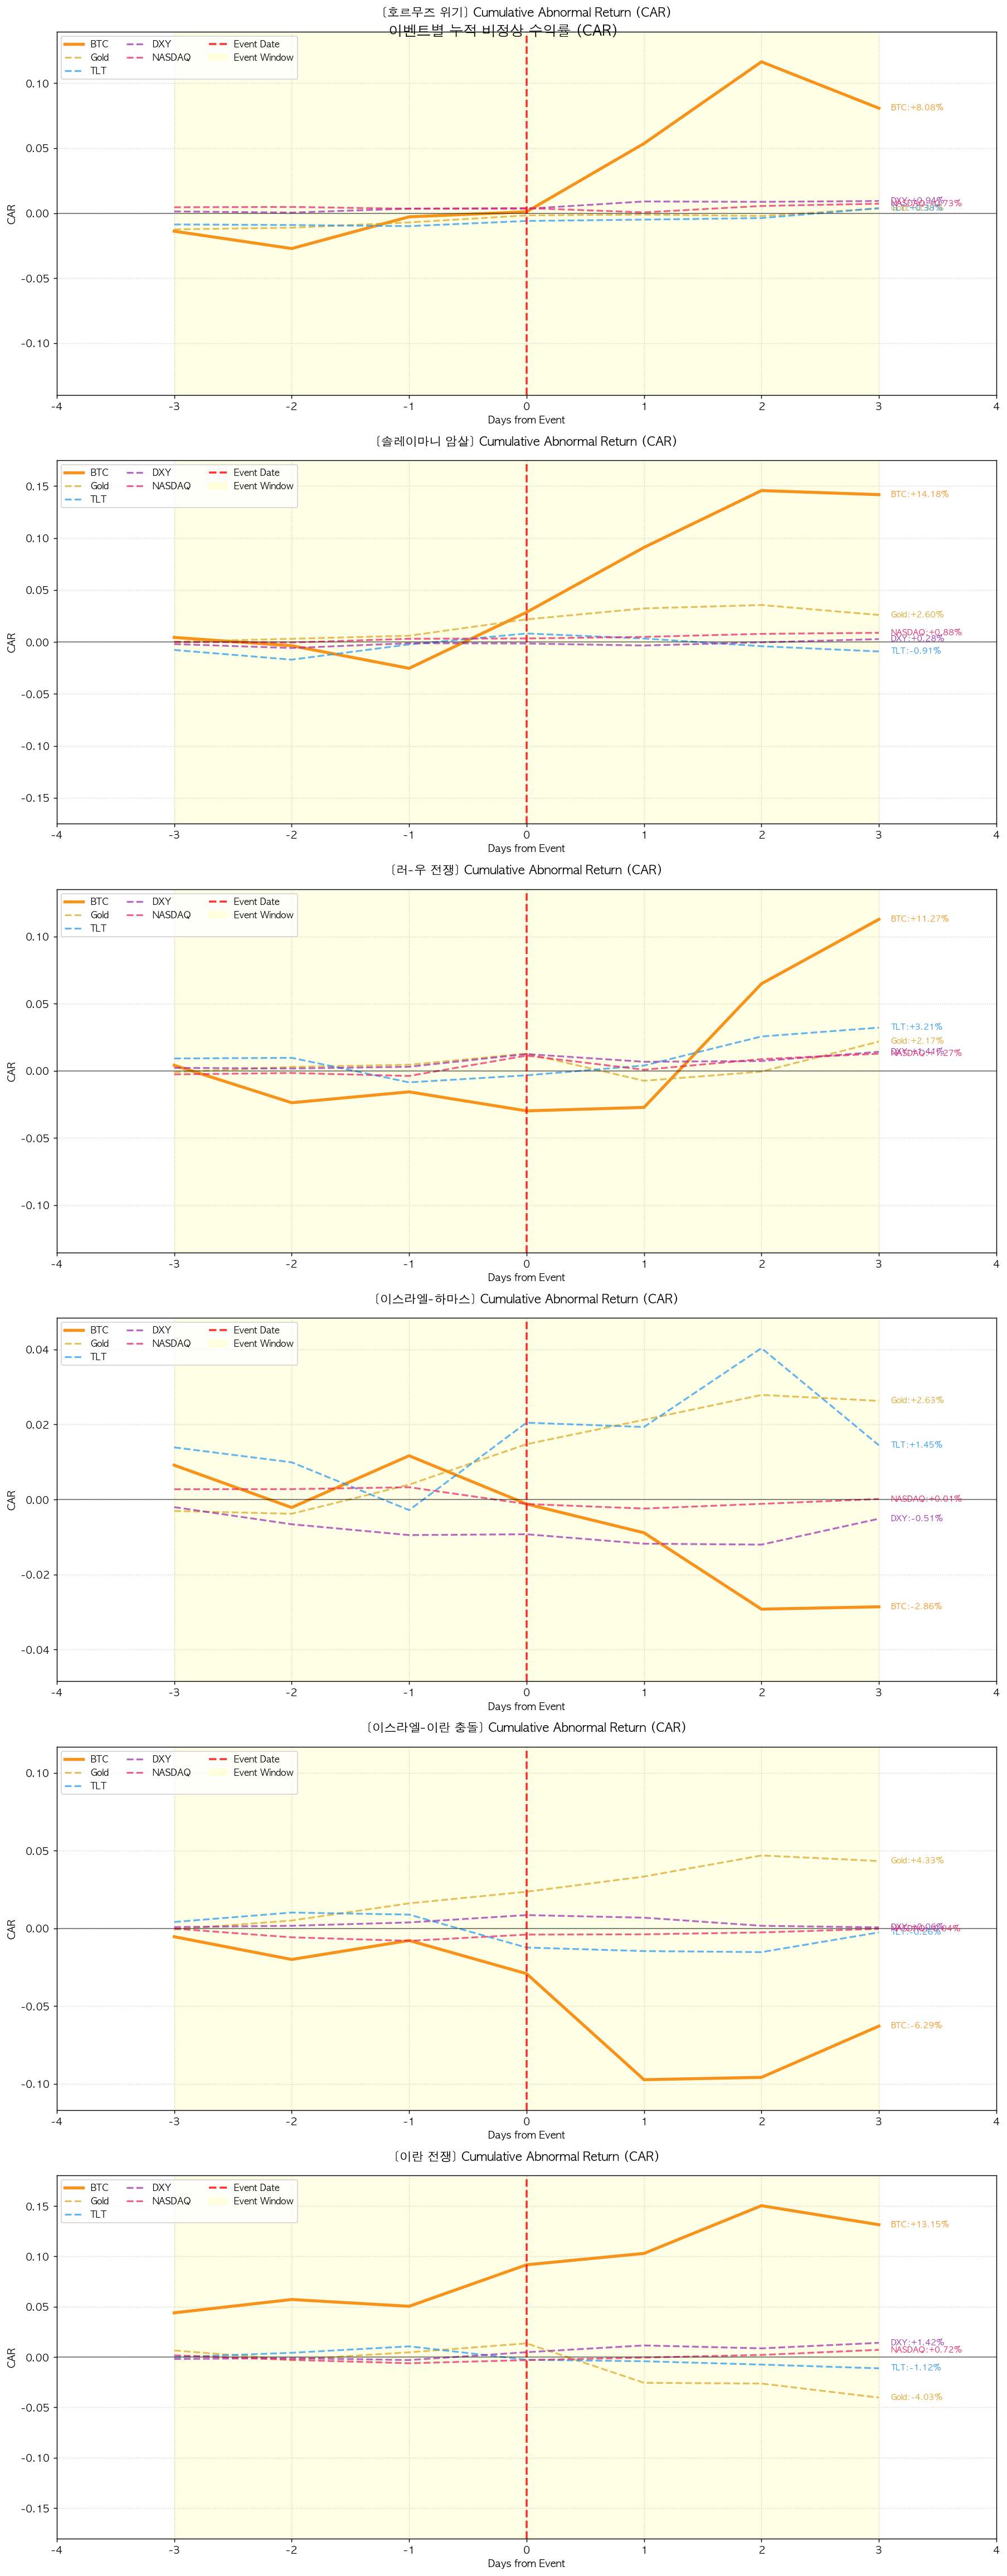

✅ event_study_CAR_timeseries.png 저장


In [10]:
# ── 6-1. 이벤트별 CAR 시계열 (개선 버전) ────────────────────────
valid_events = [e for e in EVENT_DATES if car_results.get(e)]
n = len(valid_events)
fig, axes = plt.subplots(n, 1, figsize=(14, 6*n)) # 높이를 조금 더 확보
if n == 1: axes = [axes]

for ax, event in zip(axes, valid_events):
    car = car_results[event]
    max_val = 0 # Y축 범위를 결정하기 위한 변수
    
    for asset, df_ar in car.items():
        if len(df_ar) == 0: continue
        
        # 강조 로직 유지
        lw = 3.0 if asset == 'BTC' else 1.8
        ls = '-' if asset == 'BTC' else '--'
        alpha = 1.0 if asset == 'BTC' else 0.7
        
        line = ax.plot(df_ar['day_offset'], df_ar['CAR'],
                color=ASSET_COLORS.get(asset, 'gray'),
                lw=lw, ls=ls, alpha=alpha, label=asset)
        
        # 마지막 지점에 수치 텍스트 추가 (가독성 향상)
        last_val = df_ar['CAR'].iloc[-1]
        ax.text(df_ar['day_offset'].iloc[-1] + 0.1, last_val, f'{asset}:{last_val:+.2%}', 
                fontsize=8, verticalalignment='center', color=line[0].get_color(), fontweight='bold')
        
        max_val = max(max_val, abs(df_ar['CAR'].max()), abs(df_ar['CAR'].min()))

    # 그래프 세부 설정
    ax.axvline(0, color='red', lw=2, ls='--', alpha=0.8, label='Event Date')
    ax.axhline(0, color='black', lw=1.0, alpha=0.5)
    
    # 이벤트 창 강조 영역 (전후 3일)
    ax.axvspan(-EVENT_WINDOW, EVENT_WINDOW, color='yellow', alpha=0.1, label='Event Window')
    
    # Y축 범위를 데이터에 맞춰 대칭으로 설정 (비교 용이)
    buffer = max_val * 0.2 if max_val > 0 else 0.1
    ax.set_ylim(-max_val - buffer, max_val + buffer)
    
    ax.set_xlim(-EVENT_WINDOW - 1, EVENT_WINDOW + 1)
    ax.set_title(f'[{EVENT_LABELS.get(event,event)}] Cumulative Abnormal Return (CAR)', 
                 fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel('Days from Event')
    ax.set_ylabel('CAR')
    ax.legend(fontsize=9, loc='upper left', ncol=3)
    ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('이벤트별 누적 비정상 수익률 (CAR)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('event_study_CAR_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ event_study_CAR_timeseries.png 저장')

In [11]:
# [복구] sig_results 데이터 강제 생성 루프
sig_results = []

for event, date in EVENT_DATES.items():
    car_data = car_results.get(event, {})
    model_ev = models_v4.get(event, {})
    est_df = estimation_data.get(event, pd.DataFrame())

    for asset in ASSETS:
        df_ar = car_data.get(asset)
        if df_ar is None or len(df_ar) == 0: continue
        
        params = model_ev.get(asset)
        if not params: continue

        # AR 및 검정 데이터 산출
        est_normal = est_df.apply(lambda r: normal_return(r.to_dict(), params), axis=1)
        est_ar = est_df[asset] - est_normal
        
        # 검정 실행
        car_val, t_bmp, p_bmp = ttest_car_bmp_robust(df_ar['AR'], est_ar)
        p_block = bootstrap_block_car(df_ar['AR'], est_ar)

        # 결과 저장
        sig_results.append({
            'event': event, 
            'asset': asset, 
            'CAR': car_val,
            't_stat': t_bmp, 
            'p_norm': p_bmp, # 막대그래프 코드에서 쓰는 이름과 맞춤
            'p_boot': p_block
        })

print(f"✅ 복구 완료: {len(sig_results)}개의 결과 데이터가 생성되었습니다.")

# ── Baur & Lucey (2010) 라벨링: label/sig/p_t 컬럼 보충 ──
import pandas as pd
def _label_baur_lucey(asset, CAR, p):
    if pd.isna(CAR) or pd.isna(p):
        return '⚪ 비유의', False
    if p >= 0.05:
        return '⚪ 비유의', False
    if CAR > 0:
        return '🟢 Safe Haven' if asset in ('BTC','Gold') else '🔵 Co-mover (+)', True
    else:
        return '🔴 Risky Asset', True

for _r in sig_results:
    _lbl, _sig = _label_baur_lucey(_r['asset'], _r['CAR'], _r.get('p_norm'))
    _r['p_t']   = _r.get('p_norm')
    _r['sig']   = _sig
    _r['label'] = _lbl
print(f"✅ label/sig/p_t 컬럼 보충 완료 (총 {len(sig_results)}건)")


✅ 복구 완료: 30개의 결과 데이터가 생성되었습니다.
✅ label/sig/p_t 컬럼 보충 완료 (총 30건)


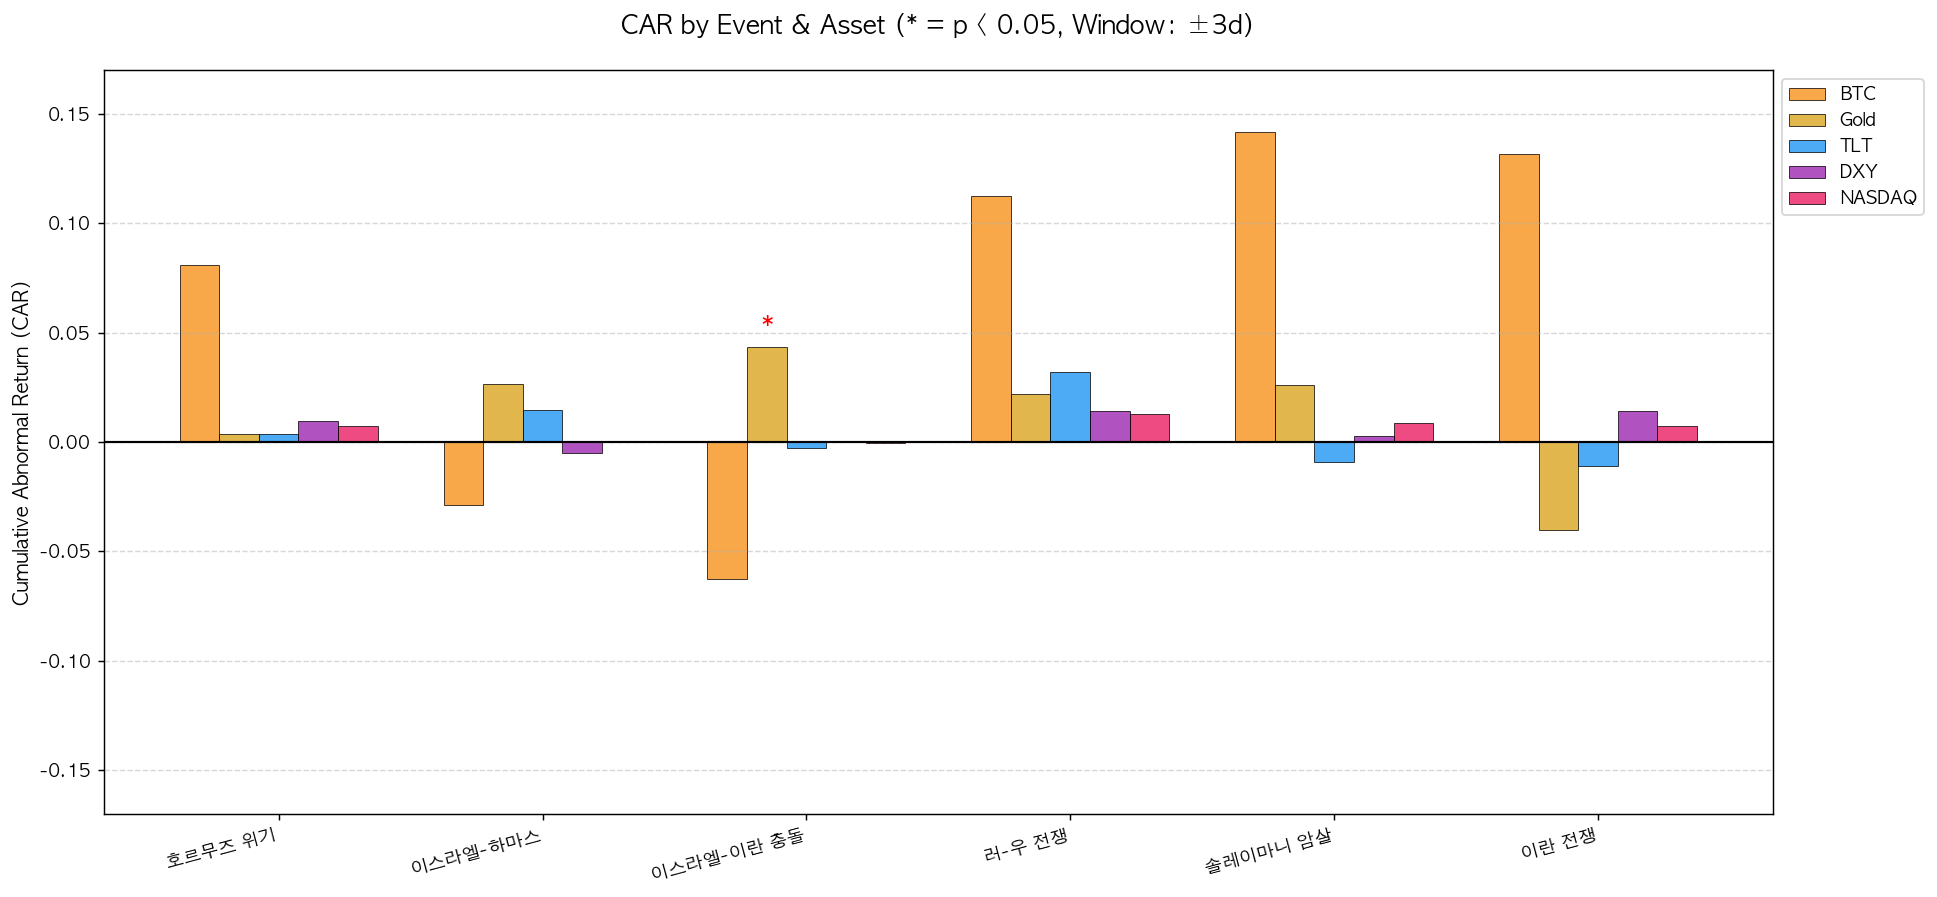

In [12]:
# ── 6-2. 자산별 × 이벤트별 CAR 막대그래프 (개선 버전) ──────────
if len(sig_results) == 0:
    print('결과 데이터(sig_results)가 없습니다.')
else:
    # 데이터프레임 변환
    sig_df = pd.DataFrame(sig_results)
    
    # 피벗 테이블 생성
    pivot = sig_df.pivot_table(
        index='event', columns='asset', values='CAR', aggfunc='first'
    ).reindex(columns=ASSETS)

    x = np.arange(len(pivot))
    width = 0.15
    fig, ax = plt.subplots(figsize=(15, 7))
    
    # 자산별 색상 매핑 (기존 ASSET_COLORS 활용 권장)
    clrs = ['#F7931A','#DAA520','#2196F3','#9C27B0','#E91E63'] 

    for i, asset in enumerate(ASSETS):
        if asset not in pivot.columns: continue
        
        vals = pivot[asset].fillna(0).values
        # 막대 그리기
        bars = ax.bar(x + i*width, vals, width, 
                      label=asset, color=clrs[i], alpha=0.8, edgecolor='black', lw=0.5)
        
        # 유의성 표시 (별표)
        for j, (bar, ev) in enumerate(zip(bars, pivot.index)):
            row = sig_df[(sig_df['event']==ev) & (sig_df['asset']==asset)]
            if len(row) > 0:
                # p_bmp 또는 p_norm 사용 (본인의 데이터프레임 컬럼명 확인)
                p_val = row['p_norm'].values[0] 
                if pd.notna(p_val) and p_val < 0.05:
                    height = bar.get_height()
                    yoff = height * 0.05 if height >= 0 else height * 0.05 - 0.01
                    ax.text(bar.get_x() + bar.get_width()/2, 
                            height + yoff, '*', 
                            ha='center', va='bottom' if height >= 0 else 'top',
                            fontsize=16, color='red', fontweight='bold')

    # 그래프 디자인
    ax.axhline(0, color='black', lw=1.2)
    ax.set_xticks(x + width * (len(ASSETS)-1)/2)
    ax.set_xticklabels([EVENT_LABELS.get(e, e) for e in pivot.index], 
                       rotation=15, ha='right', fontsize=10)
    
    ax.set_ylabel('Cumulative Abnormal Return (CAR)', fontsize=11)
    ax.set_title(f'CAR by Event & Asset (* = p < 0.05, Window: ±{EVENT_WINDOW}d)', 
                 fontsize=14, fontweight='bold', pad=20)
    
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10) # 범례를 밖으로 빼서 그래프 확보
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Y축 범위를 % 단위로 보기 좋게 설정
    vals_all = pivot.values.flatten()
    ylim = max(abs(np.nanmin(vals_all)), abs(np.nanmax(vals_all))) * 1.2
    ax.set_ylim(-ylim, ylim)

    plt.tight_layout()
    plt.savefig('event_study_CAR_bar_final.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Step 7. Baur & Lucey (2010) 최종 분류

| 조건 | 분류 |
|------|------|
| CAR > 0 & p < 0.05 | Safe Haven ✅ |
| CAR > 0 & p ≥ 0.05 | Diversifier |
| CAR < 0 & p < 0.05 | Risky Asset ❌ |
| CAR < 0 & p ≥ 0.05 | 비유의 |


In [13]:
if len(sig_df) == 0:
    print('결과 없음')
else:
    print('=' * 80)
    print('Baur & Lucey (2010) 최종 분류')
    print('=' * 80)

    # BTC 요약
    btc_df = sig_df[sig_df['asset'] == 'BTC'].copy()
    print(f'\n▶ BTC Safe-Haven 가설 검증:\n')
    summary = []
    for _, r in btc_df.iterrows():
        lbl = r['label'].replace('🟢 ','').replace('🔴 ','').replace('🔵 ','').replace('⚪ ','')
        summary.append({
            '이벤트'    : EVENT_LABELS.get(r['event'], r['event']),
            'CAR'       : round(r['CAR'], 4),
            'p-value(t)': round(r['p_t'], 4),
            'p-boot'    : round(r['p_boot'], 4) if pd.notna(r['p_boot']) else '-',
            '유의(5%)'  : r['sig'],
            '결론'      : r['label'],
        })
    display(pd.DataFrame(summary).set_index('이벤트'))

    # 전체 자산 피벗
    print('\n▶ 전체 자산 분류표:\n')
    pivot_lbl = sig_df.pivot_table(
        index='event', columns='asset', values='label', aggfunc='first'
    )
    pivot_lbl.index = [EVENT_LABELS.get(e,e) for e in pivot_lbl.index]
    display(pivot_lbl)

Baur & Lucey (2010) 최종 분류

▶ BTC Safe-Haven 가설 검증:



,CAR,p-value(t),p-boot,유의(5%),결론
이벤트,,,,,
호르무즈 위기,0.0808,0.4359,0.2356,False,⚪ 비유의
솔레이마니 암살,0.1418,0.1803,0.2270,False,⚪ 비유의
러-우 전쟁,0.1127,0.3375,0.2390,False,⚪ 비유의
이스라엘-하마스,-0.0286,0.4172,0.5342,False,⚪ 비유의
이스라엘-이란 충돌,-0.0629,0.4813,0.4158,False,⚪ 비유의
이란 전쟁,0.1315,0.1065,0.0100,False,⚪ 비유의



▶ 전체 자산 분류표:



asset,BTC,DXY,Gold,NASDAQ,TLT
호르무즈 위기,⚪ 비유의,⚪ 비유의,⚪ 비유의,⚪ 비유의,⚪ 비유의
이스라엘-하마스,⚪ 비유의,⚪ 비유의,⚪ 비유의,⚪ 비유의,⚪ 비유의
이스라엘-이란 충돌,⚪ 비유의,⚪ 비유의,🟢 Safe Haven,⚪ 비유의,⚪ 비유의
러-우 전쟁,⚪ 비유의,⚪ 비유의,⚪ 비유의,⚪ 비유의,⚪ 비유의
솔레이마니 암살,⚪ 비유의,⚪ 비유의,⚪ 비유의,⚪ 비유의,⚪ 비유의
이란 전쟁,⚪ 비유의,⚪ 비유의,⚪ 비유의,⚪ 비유의,⚪ 비유의


---
## Step 8. 결과 저장


In [14]:
# 검정 결과
sig_df.to_csv('event_study_results.csv', index=False, encoding='utf-8-sig')

# AR 시계열 (이벤트별 × 자산별)
ar_rows = []
for event, car in car_results.items():
    for asset, df_ar in car.items():
        tmp = df_ar.copy()
        tmp['event_name'] = event
        tmp['asset']      = asset
        ar_rows.append(tmp)
if ar_rows:
    pd.concat(ar_rows, ignore_index=True).to_csv(
        'event_study_AR_timeseries.csv', index=False, encoding='utf-8-sig')

print('▶ 최종 산출물:')
for f in ['event_study_results.csv',
          'event_study_AR_timeseries.csv',
          'event_study_CAR_timeseries.png',
          'event_study_CAR_bar.png']:
    flag = '✅' if os.path.exists(f) else '📄 (실행 후 생성)'
    print(f'  {flag} {f}')

▶ 최종 산출물:
  ✅ event_study_results.csv
  ✅ event_study_AR_timeseries.csv
  ✅ event_study_CAR_timeseries.png
  📄 (실행 후 생성) event_study_CAR_bar.png


**EDA 결론 및 한계**

- BTC는 높은 고유 변동성으로 인해 통계적 유의성 확보가 어려움
- 안전자산 성격이 이벤트별로 비일관적 → GARCH·분위 회귀 추가 분석 필요
